# 1. Problem Statement

- Netflix is a global media streaming company, with over 10,000 movies, TV shows and regional content avilable in multiple languages
- Netflix has over 222 Million subscribers globally.
- Netflix want to explore possible areas of opporunities to increase its reach and penetration in different coutries and hence increase revenue.
- In addition to this, we want to identify unsuccessful ventures to prevent leakages and improve profits.
- The ultimate aim is to present analysis of netflix data in order to support decision for business growth in different countries.
- We want to suggest which type of shows to produce to grow the business

- The exploration should have a goal.
- As you explore the data, keep in mind that you want to answer which type of shows to produce and how to grow the business.
- Ensure each recommendation is backed by data. The company is looking for data-driven insights, not personal opinions or anecdotes.
- Assume that you are presenting your findings to business executives who have only a basic understanding of data science. Avoid unnecessary technical jargon.
- Start by exploring a few questions:
    - What type of content is available in different countries?
    - How has the number of movies released per year changed over the last 20-30 years?
    - Comparison of tv shows vs. movies.
    - What is the best time to launch a TV show?
    - Analysis of actors/directors of different types of shows/movies.
    - Does Netflix has more focus on TV Shows than movies in recent years
    - Understanding what content is available in different countries

# 1. Exploring Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
netflix = pd.read_csv('netflix.csv')

In [3]:
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [4]:
netflix.set_index('show_id', inplace=True)

### 1.1 Data Preparation and Cleaning

##### Shape of Data, data types of attributes, Missing Values etc

In [5]:
netflix.shape

(8807, 11)

In [6]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8807 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   director      6173 non-null   object
 3   cast          7982 non-null   object
 4   country       7976 non-null   object
 5   date_added    8797 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 825.7+ KB


Here we can observe that all columns except release_year is in string format. So we need to change the data types of some of the columns

- Checking the number of missing Values

In [7]:
netflix.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
# Checking the rows having missing values for specific columns ['date_added', 'rating', 'duration']
netflix[netflix[['date_added', 'rating', 'duration']].isna().any(axis=1)]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...
s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."


We can observe that the rating column for indexes s5542, s5795, s5814 contains the value of duration.
- so we can fill the empty duration values for these rows and search online for their rating value.

In [9]:
# entering the rating values to duration values
indexes = netflix[netflix['duration'].isna()].index

In [10]:
indexes

Index(['s5542', 's5795', 's5814'], dtype='object', name='show_id')

In [11]:
netflix.loc[indexes, 'duration'] = netflix.loc[indexes, 'rating']

In [12]:
netflix.loc[indexes, 'rating'] = np.nan

In [13]:
netflix.loc[indexes]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...


In [14]:
netflix.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [15]:
# Now the rating columns have 7 missing values, we can just enter the correct value based on some online search for that title

In [16]:
indexes = netflix[netflix['rating'].isna()].index

In [17]:
indexes

Index(['s5542', 's5795', 's5814', 's5990', 's6828', 's7313', 's7538'], dtype='object', name='show_id')

In [18]:
netflix.loc[indexes]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...
s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [19]:
netflix[netflix['type']=='Movie']['rating'].unique()

array(['PG-13', 'PG', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y', 'R', 'TV-G',
       'TV-Y7', 'G', 'NC-17', nan, 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [20]:
replacement = pd.Series(['TV-MA', 'TV-MA', 'TV-MA', 'TV-PG', 'TV-14', 'TV-MA', 'PG-13'], index=indexes)

In [21]:
replacement

show_id
s5542    TV-MA
s5795    TV-MA
s5814    TV-MA
s5990    TV-PG
s6828    TV-14
s7313    TV-MA
s7538    PG-13
dtype: object

In [22]:
netflix.loc[indexes, 'rating'] = replacement

In [23]:
netflix.loc[indexes]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,TV-MA,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,TV-MA,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,TV-MA,66 min,Movies,The comic puts his trademark hilarious/thought...
s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,TV-PG,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,TV-14,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,TV-MA,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,PG-13,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [24]:
netflix.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

Now We have cleared the missing values from Duration and ratings columns

In [26]:
# Converting date_added column to datetime
netflix['date_added'] = pd.to_datetime(netflix['date_added'].str.strip())

In [27]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8807 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8807 non-null   object        
 1   title         8807 non-null   object        
 2   director      6173 non-null   object        
 3   cast          7982 non-null   object        
 4   country       7976 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8807 non-null   int64         
 7   rating        8807 non-null   object        
 8   duration      8807 non-null   object        
 9   listed_in     8807 non-null   object        
 10  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 1.1+ MB


In [28]:
netflix.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [29]:
# Checking the rows which have missing date_added values
netflix[netflix['date_added'].isnull()]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."


All the rows having missing date_added column are from TV show categories. I am deciding to drop these rows as i think it will not affect the analysis too much.

In [38]:
netflix.dropna(subset=['date_added'], axis=0, inplace=True)

In [39]:
netflix.isna().sum()

type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

Hence we have cleared the data, removed missing values, corrected data types, and removed erroneous values in the data.

### Analysis of top Countries where the netflix content is streaming
to find out the top countries, we need to see the countries column and count the number of times any country is appeaaring in the countries.
The challenge is to count where there are multiple countries.

In [43]:
netflix.head(10)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [54]:
def count_countries(df):
    countries = {}
    for country_list in df.country:
        print(type(country_list))
        if type(country_list) != float:
            for country in [country_name.strip() for country_name in country_list.split(',')]:
                countries[country] = countries.get(country, 0) + 1

    return countries        

In [94]:
# countries = count_countries(netflix)

In [93]:
# countries

In [65]:
top_countries = {country:countries[country] for country in countries.keys() if countries[country] > 10}

In [92]:
# top_countries

In [68]:
top_countries = dict(sorted(top_countries.items(), key=lambda item: item[1], reverse=True))

In [70]:
top_countries = pd.Series(data=top_countries.values(), index=top_countries.keys())

In [91]:
# top_countries

In [95]:
def is_among_top_10(x, top_coutries):
    if type(x) != float:
        for item in x.split(','):
            if item.strip() in top_countries[:11]:
                return True

    return False    

top_10_movies_countries = netflix.loc[(netflix['type']=='Movie') & (netflix['country'].apply(lambda x: is_among_top_10(x, top_countries)))]

top_10_movies_countries

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...
s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,2018-02-15,2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


### 1.2 Comparison of Movies & TV shows on netflix

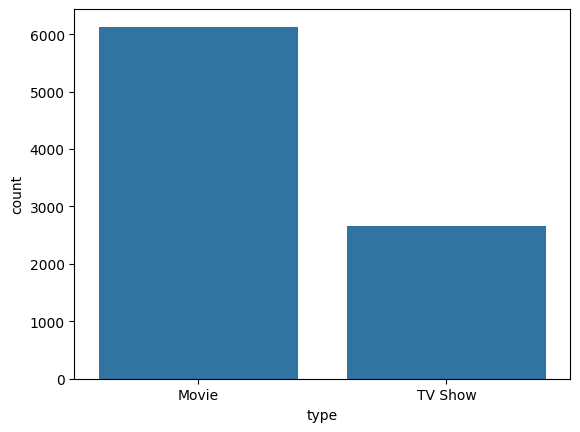

In [99]:
sns.countplot(data=netflix, x='type')
plt.show()

We can see that netflix has more focus on movies than TV Shows

### 1.3 How has the number of movies and TV Shows release changed over the years

In [100]:
# Bifurcation of Movies and TV shows for analysis
movies = netflix[netflix['type']=='Movie']
tv_shows = netflix[netflix['type']=='TV Show']

In [103]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6131 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          6131 non-null   object        
 1   title         6131 non-null   object        
 2   director      5943 non-null   object        
 3   cast          5656 non-null   object        
 4   country       5691 non-null   object        
 5   date_added    6131 non-null   datetime64[ns]
 6   release_year  6131 non-null   int64         
 7   rating        6131 non-null   object        
 8   duration      6131 non-null   object        
 9   listed_in     6131 non-null   object        
 10  description   6131 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 574.8+ KB


In [104]:
tv_shows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2666 entries, s2 to s8804
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          2666 non-null   object        
 1   title         2666 non-null   object        
 2   director      230 non-null    object        
 3   cast          2316 non-null   object        
 4   country       2276 non-null   object        
 5   date_added    2666 non-null   datetime64[ns]
 6   release_year  2666 non-null   int64         
 7   rating        2666 non-null   object        
 8   duration      2666 non-null   object        
 9   listed_in     2666 non-null   object        
 10  description   2666 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 249.9+ KB


In [109]:
movies_added_year = movies.groupby(movies['date_added'].dt.year).size()

In [113]:
tv_shows_released_year = tv_shows.groupby(tv_shows['date_added'].dt.year).size()
tv_shows_released_year

date_added
2008      1
2013      5
2014      5
2015     26
2016    176
2017    349
2018    412
2019    592
2020    595
2021    505
dtype: int64

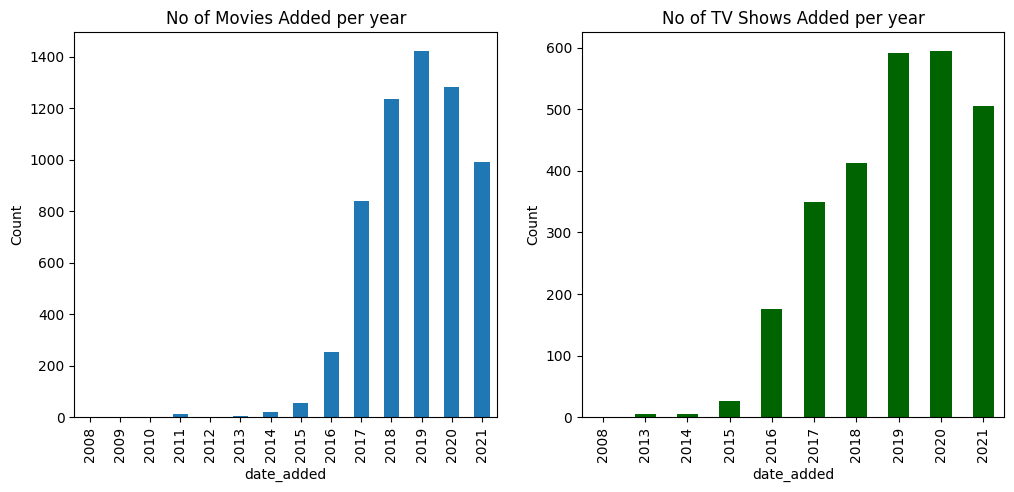

In [121]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
movies_added_year.plot(kind='bar')
plt.title('No of Movies Added per year')
plt.ylabel('Count')
plt.subplot(1, 2, 2)
tv_shows_released_year.plot(kind='bar', color='darkgreen')
plt.title('No of TV Shows Added per year')
plt.ylabel('Count')
plt.show()

Here we can see that the number of Movies and TV shows being added were increasing till 2019 and started decreasing after that

### 1.4 What is the best time to launch a TV show?

In [128]:
import calendar
month_order = list(calendar.month_name[1:])
month_order

['January',
 'February',
 'March',
 'April',
 'May',
 'June',
 'July',
 'August',
 'September',
 'October',
 'November',
 'December']

In [133]:
tv_show_release = tv_shows.groupby(tv_shows['date_added'].dt.month_name()).size()
tv_show_release = tv_show_release.reindex(month_order, fill_value=0)
# tv_show_release

In [134]:
movie_release = movies.groupby(movies['date_added'].dt.month_name()).size()
movie_release = movie_release.reindex(month_order, fill_value=0)
# movie_release

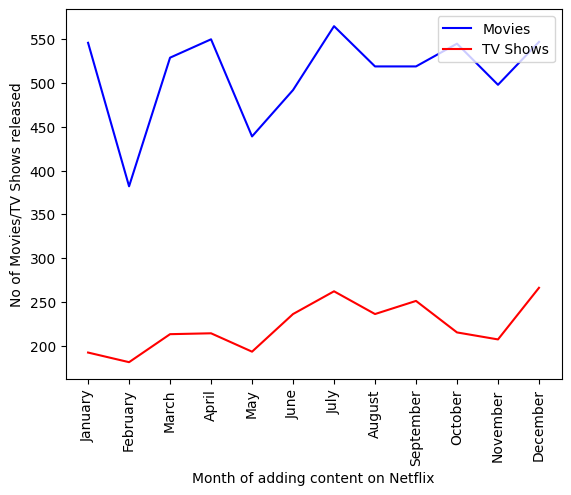

In [137]:
plt.plot(movie_release.index, movie_release.values, color='b', label='Movies')
plt.plot(tv_show_release.index, tv_show_release.values, color='r', label='TV Shows')
plt.legend(loc='upper right')
plt.xlabel('Month of adding content on Netflix')
plt.xticks(rotation=90)
plt.ylabel('No of Movies/TV Shows released')
plt.show()

<Axes: xlabel='date_added'>

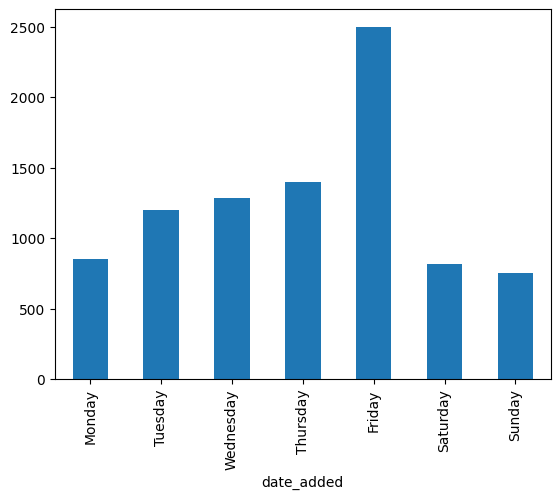

In [156]:
# Identifying what is the best time of a week to release new content on netflix
netflix.groupby(netflix['date_added'].dt.day_name()).size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                                                                    fill_value=0).plot(kind='bar')

In [141]:
# The best time of the week to release new content is friday as it marks the beginning of the weekend.

We can clearly see a pattern here. So the best time to release any Movie/TV show during a year is July-August and December-January.
This can bee associated to the vacation and holiday season scross the world. So it would benefit the veiwership

### 1.5 Analysis of Top Genres in Movies and TV Shows

In [142]:
def count_genre(df):
    count = {}
    for genre in df.listed_in:
        for item in [x.strip() for x in genre.split(',')]:
            count[item] = count.get(item, 0)+1
    return count

In [145]:
movies_genre = count_genre(movies)
movies_genre_count = pd.Series(data=movies_genre.values(), index=movies_genre.keys())
movies_genre_count

Documentaries                869
Children & Family Movies     641
Dramas                      2427
Independent Movies           756
International Movies        2752
Comedies                    1674
Thrillers                    577
Romantic Movies              616
Music & Musicals             375
Horror Movies                357
Sci-Fi & Fantasy             243
Action & Adventure           859
Classic Movies               116
Anime Features                71
Sports Movies                219
Cult Movies                   71
Faith & Spirituality          65
LGBTQ Movies                 102
Stand-Up Comedy              343
Movies                        57
dtype: int64

In [146]:
tv_genre = count_genre(tv_shows)
tv_genre_count = pd.Series(data=tv_genre.values(), index=tv_genre.keys())
tv_genre_count

International TV Shows          1350
TV Dramas                        762
TV Mysteries                      98
Crime TV Shows                   469
TV Action & Adventure            167
Docuseries                       394
Reality TV                       255
Romantic TV Shows                370
TV Comedies                      574
TV Horror                         75
British TV Shows                 252
Spanish-Language TV Shows        173
TV Thrillers                      57
Kids' TV                         449
TV Sci-Fi & Fantasy               83
Anime Series                     175
Korean TV Shows                  151
Science & Nature TV               92
Teen TV Shows                     69
TV Shows                          16
Stand-Up Comedy & Talk Shows      56
Classic & Cult TV                 26
dtype: int64

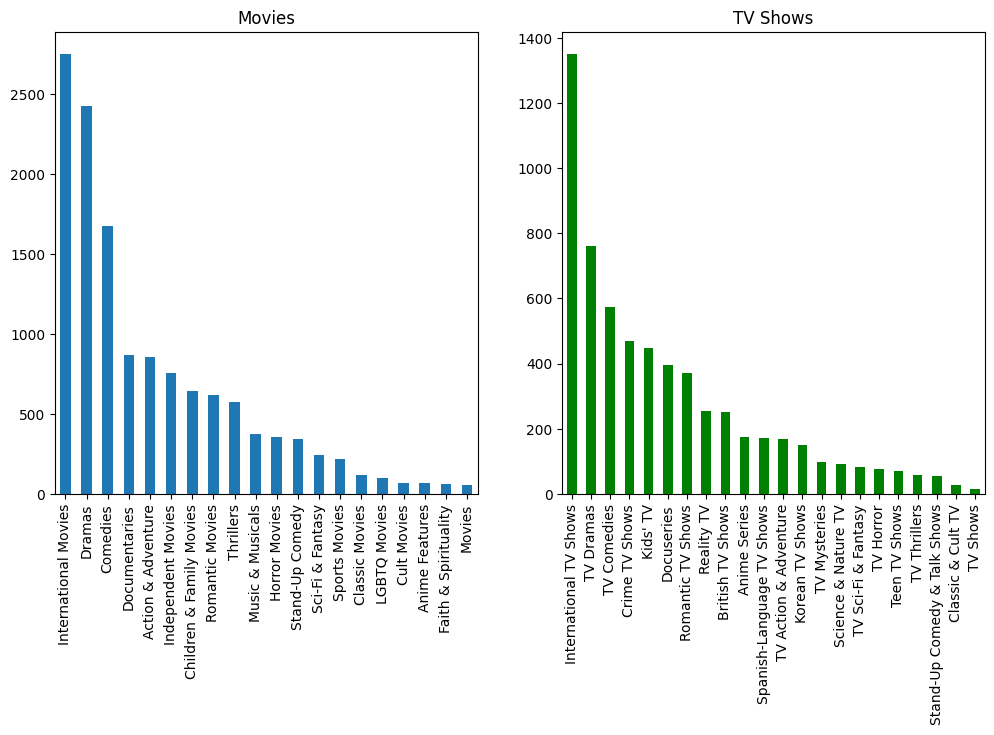

In [155]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
movies_genre_count.sort_values(ascending=False).plot(kind='bar')
plt.title('Movies')
plt.subplot(1, 2, 2)
tv_genre_count.sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('TV Shows')
plt.show()

Here We can see that the top are International Movies/TV Shows, Dramas, comedies, documentaries, crime, Action& Adventure etc. 
So the company can focus on these genre to increase veiwership

In [164]:
# # How does the duration of Movies and TV shows varies.
# movies['duration'] = movies['duration'].apply(lambda x: x.str[:-4].astype(int))

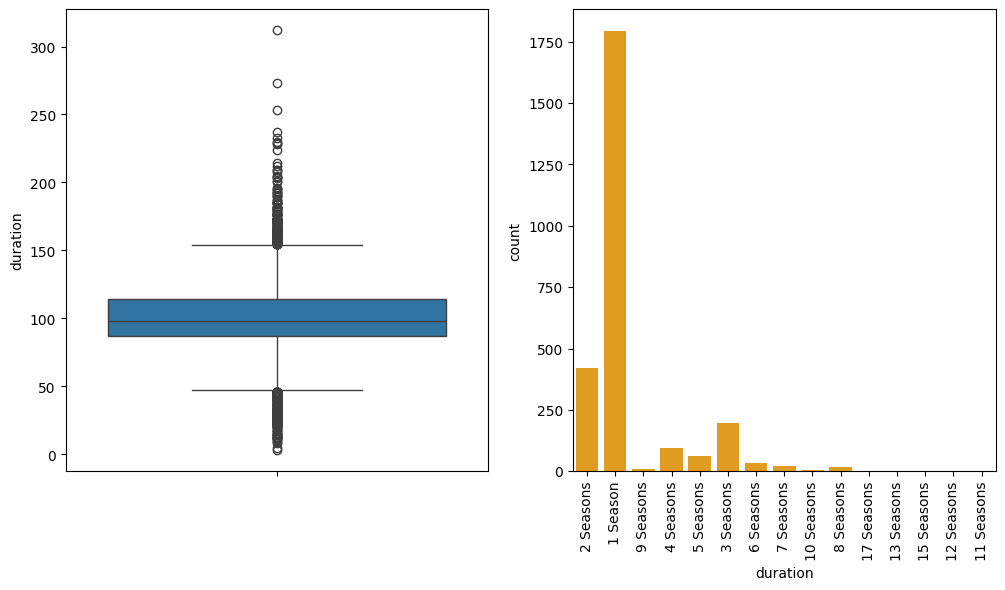

In [177]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=movies, y='duration', ax=ax[0])
sns.countplot(data=tv_shows, x='duration', ax=ax[1], color='orange')
plt.xticks(rotation=90)
plt.show()